# Seeded PA VAE experiments

In [1]:
from svae import PROFILES, generators_from_run, train
from svae.evaluate import (
    graph_samples_experiment,
    graph_statistics_experiment,
    reconstruction_experiment,
    timing_experiment,
    structural_invariants_experiment
)

config = PROFILES["large"]

In [2]:
config

Config(profile='large', num_nodes=256, latent_dim=128, hidden=512, train_graphs=32768, val_graphs=4096, test_graphs=4096, generated_graphs=2048, batch_size=256, epochs=100, lr=0.001, beta=1.0, warmup_epochs=15, init_seed=20260909, threads=8)

{'train': (32768, 256), 'validation': (4096, 256), 'test': (4096, 256)}


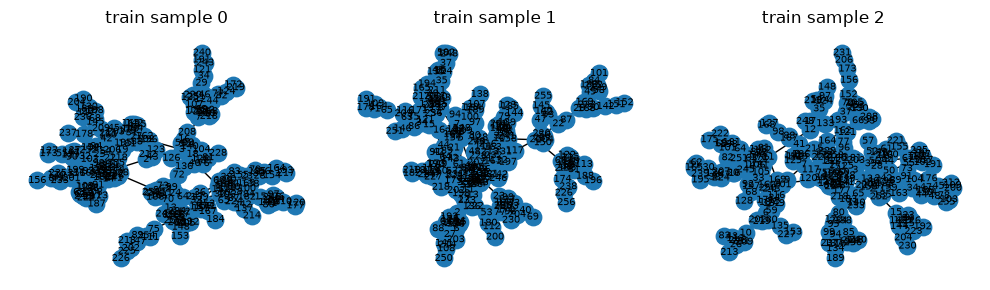

{'epoch': 1.0, 'beta': 0.06666666666666667, 'train_recon_query': 4.337747641435758, 'train_kl_graph': 8.522471528034657, 'val_recon_query': 4.302191005917046, 'val_kl_graph': 18.250871062278748}
{'epoch': 2.0, 'beta': 0.13333333333333333, 'train_recon_query': 4.291161330666129, 'train_kl_graph': 14.099212996661663, 'val_recon_query': 4.27735681608906, 'val_kl_graph': 16.069066643714905}
{'epoch': 3.0, 'beta': 0.2, 'train_recon_query': 4.269948719054695, 'train_kl_graph': 14.39733350276947, 'val_recon_query': 4.259675634188915, 'val_kl_graph': 14.434566736221313}
{'epoch': 4.0, 'beta': 0.26666666666666666, 'train_recon_query': 4.254173567914587, 'train_kl_graph': 14.147351443767548, 'val_recon_query': 4.246395471527821, 'val_kl_graph': 13.921610116958618}
{'epoch': 5.0, 'beta': 0.3333333333333333, 'train_recon_query': 4.244269187056173, 'train_kl_graph': 13.635642871260643, 'val_recon_query': 4.240302198515163, 'val_kl_graph': 13.166858494281769}
{'epoch': 6.0, 'beta': 0.4, 'train_recon

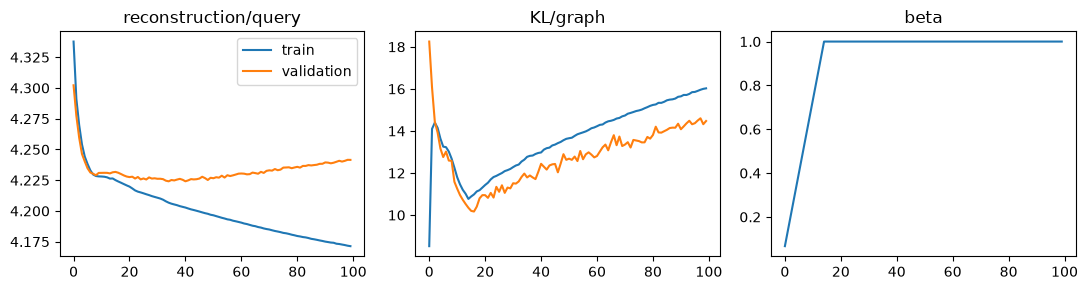

In [3]:
run = train(config)

In [2]:
# Load a run from a checkpoint instead of training above.
# Splits are not stored in the checkpoint, so they are re-simulated here. Simulation runs
# ~0.9 ms/graph at 256 nodes, so a full 262k-graph training split costs minutes.
# Downstream code only reads:
#   data.train -> IndependentParentGenerator's per-query parent marginals (subsample is fine)
#   data.test  -> the "NetworkX" reference collection and the reconstruction/probe diagnostics
# data.validation is never read, so it is left empty.
from dataclasses import fields
from pathlib import Path

import torch

from svae import ARTIFACTS_DIR, Config, DataSplits, QueryVAE, TrainingRun
from svae.simulate import make_parent_dataset
from svae.train import resolve_device

CHECKPOINT = ARTIFACTS_DIR / "seeded_pa_vae_xlarge_256_best.pt"
BASELINE_TRAIN_GRAPHS = 16_384  # None -> the config's full train_graphs
TEST_GRAPHS = None  # None -> the config's full test_graphs


def load_run(
    path, device=None, train_graphs=BASELINE_TRAIN_GRAPHS, test_graphs=TEST_GRAPHS
):
    payload = torch.load(path, map_location="cpu", weights_only=False)
    known = {field.name for field in fields(Config)}
    loaded_config = Config(**{
        name: value for name, value in payload["config"].items() if name in known
    })
    selected_device = resolve_device(device)
    model = QueryVAE(
        loaded_config.num_nodes, loaded_config.latent_dim, loaded_config.hidden
    ).to(selected_device)
    model.load_state_dict(payload["model_state_dict"])
    model.eval()
    # Same seed streams as make_data_splits, just truncated: a true subset of each split.
    data = DataSplits(
        train=make_parent_dataset(
            loaded_config.num_nodes,
            min(train_graphs or loaded_config.train_graphs, loaded_config.train_graphs),
            first_seed=0,
        ),
        validation=torch.zeros((0, loaded_config.num_nodes), dtype=torch.long),
        test=make_parent_dataset(
            loaded_config.num_nodes,
            min(test_graphs or loaded_config.test_graphs, loaded_config.test_graphs),
            first_seed=2_000_000,
        ),
    )
    history = tuple(payload.get("history", ()))
    return TrainingRun(
        config=loaded_config,
        model=model,
        data=data,
        history=history,
        best_validation_objective=payload["best_validation_objective_per_graph"],
        selected_epoch=payload.get("selected_epoch", len(history)),
        stopped_early=payload.get("stopped_early", False),
        elapsed_seconds=float("nan"),
        device=selected_device,
        checkpoint_path=Path(path),
    )


run = load_run(CHECKPOINT)
config = run.config  # later cells read num_nodes/threads from this
config

Config(profile='xlarge_256', num_nodes=256, latent_dim=128, hidden=512, train_graphs=262144, val_graphs=8192, test_graphs=8192, generated_graphs=4096, batch_size=256, epochs=150, lr=0.0003, beta=1.0, warmup_epochs=20, early_stopping_patience=12, early_stopping_min_delta=0.0, init_seed=20260909, threads=8)

In [3]:
generators = generators_from_run(run)

In [4]:
reconstruction = reconstruction_experiment(run)

{'mean_latent_test_parent_accuracy': 0.11946166031003937, 'mean_latent_test_cross_entropy': 4.033965666463056, 'note': 'reconstruction diagnostic; not fresh generation or marginal likelihood'}


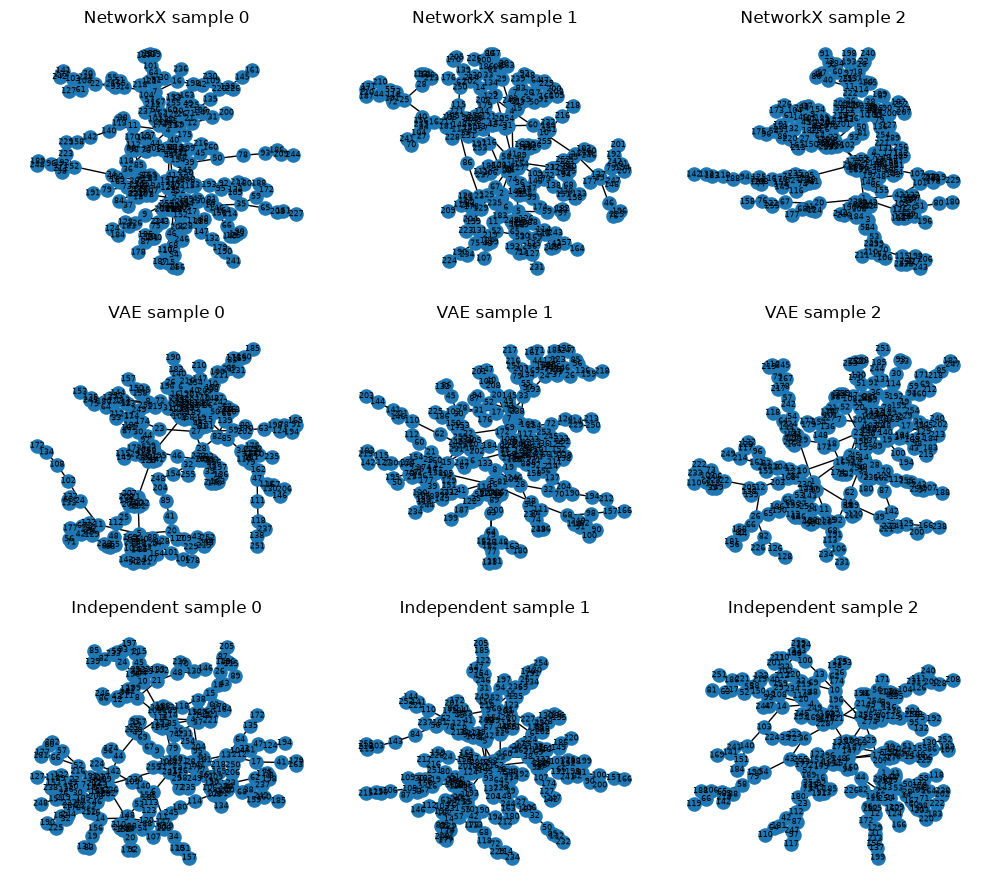

In [5]:
# Generate collections of graphs
collections = graph_samples_experiment(
    run, generators["vae"], generators["independent"]
)

Hub/leaf summary: {
  "NetworkX": {
    "max_degree_mean": 30.7989501953125,
    "max_degree_sd": 9.594602004101143,
    "leaf_fraction_mean": 0.6642122268676758,
    "leaf_fraction_sd": 0.021065046289226876
  },
  "VAE": {
    "max_degree_mean": 30.794189453125,
    "max_degree_sd": 9.608089562067946,
    "leaf_fraction_mean": 0.6295690536499023,
    "leaf_fraction_sd": 0.022524728542700576
  },
  "Independent": {
    "max_degree_mean": 20.41064453125,
    "max_degree_sd": 3.189547026085157,
    "leaf_fraction_mean": 0.5948495864868164,
    "leaf_fraction_sd": 0.018770025059809077
  }
}


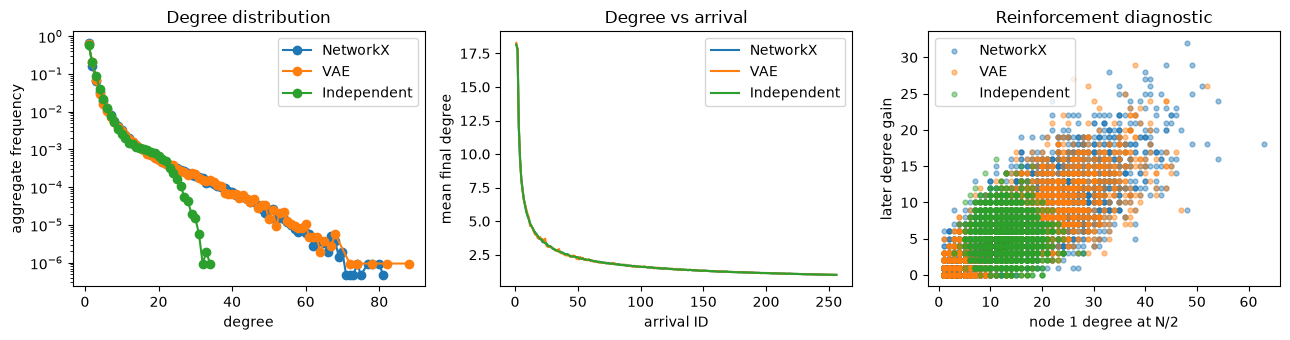

Reinforcement: {
  "NetworkX": {
    "pearson": 0.808674865837666,
    "bootstrap_95pct": [
      0.8013213799530121,
      0.8165311673520194
    ],
    "undefined_resamples": 0
  },
  "VAE": {
    "pearson": 0.802857720578628,
    "bootstrap_95pct": [
      0.7904345730306944,
      0.8133688211944432
    ],
    "undefined_resamples": 0
  },
  "Independent": {
    "pearson": 0.009495593829649355,
    "bootstrap_95pct": [
      -0.018998604722716052,
      0.03718529602484564
    ],
    "undefined_resamples": 0
  }
}


In [7]:
statistics = graph_statistics_experiment(
    collections, num_nodes=config.num_nodes
)

In [9]:
timings = timing_experiment(
    generators["vae"], num_nodes=config.num_nodes, threads=config.threads
)

{'median_scalar_query_ms_including_latent': np.float64(0.13451450104184914), 'median_public_full_graph_ms': np.float64(26.497675498831086), 'mean_networkx_full_graph_ms': 0.5987961998471292, 'timing_environment': {'device': 'cpu float32 public decoder', 'num_nodes': 256, 'threads': 8}}


In [10]:
structural_invariants = structural_invariants_experiment(
    collections, num_nodes=config.num_nodes
)

Structural invariants (m=1)
collection             graphs   passed   failed
NetworkX                 8192     8192        0
VAE                      4096     4096        0
Independent              4096     4096        0


In [11]:
from dataclasses import replace
from svae import evaluate as ev

# TODO: this is junky, probably rework these to exist in different places, remove irrelevant ones

EVALUATION_GRAPHS = 256 # number of existing graphs used for evaluation
BOOTSTRAP_SAMPLES = 200 # bootstrap samples used to estimate uncertainty, might remove this
LATENT_SAMPLES = 100 # number of latent vectors to use
SAMPLES_PER_LATENT = 50 # number of graphs decoded from each latent vector

evaluation_collections = {
    name: graphs[:EVALUATION_GRAPHS] for name, graphs in collections.items()
}
early_nodes = tuple(range(1, min(10, config.num_nodes) + 1))
evaluation_seeds = range(5_000_000, 5_000_000 + EVALUATION_GRAPHS)
latent_seeds = range(6_000_000, 6_000_000 + LATENT_SAMPLES)

## 2. Exact BA attachment law

this graph:
y axis is ECDF, cumulative distribution function. we're looking at the cdf of the distributions of the log probabilities of each graph.
x axis is the log probabilities from all sampled graphs, we are literally just showing the distribution of the cdf.

the log probability part is that, for each graph, we compute the log probability of the graph existing under the BA process, this is a known propperty.

it's very negative for all of these because we assumulating across many graphs

wasserstein distance here is pretty good.

This is good signal, BUT it doesn't necessarily mean that the parent arrays have the same complete probability distribution, because the many different kinds of graphs could compress to have the same total log probability.

NetworkX {'mean': -1063.077946925937, 'median': -1063.6792453144749, 'sd': 25.57968353201619, 'quantiles': array([-1107.36284038, -1080.40964678, -1046.74632291, -1004.99489698])}
NetworkX Wasserstein distance to NetworkX: 0.0
VAE {'mean': -1075.7767496136246, 'median': -1079.595296819315, 'sd': 30.421979084674376, 'quantiles': array([-1124.05722027, -1095.33465134, -1059.37709538, -1000.22329867])}
VAE Wasserstein distance to NetworkX: 13.403506049048543
Independent {'mean': -1126.9594803831976, 'median': -1127.85334644378, 'sd': 13.200090187069401, 'quantiles': array([-1151.77120036, -1135.40224806, -1117.70020494, -1101.08609531])}
Independent Wasserstein distance to NetworkX: 63.88153345726043


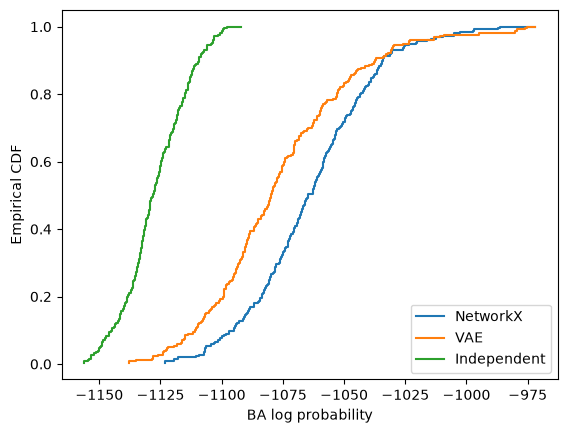

In [12]:
ba_likelihood = ev.ba_sequence_likelihood_experiment(evaluation_collections)

this one isn't super strong.

what we are doing:
we calculate the the proabability assigned to each parent recorded at t for different alphas, and then we find the probability for every attrachment and figure out which alpha makes all observed choices collectively most probable. 

We see that networkx and vae are both close to each other, close to 1, which is what we would expect 

NetworkX alpha: 1.0 95% interval: [1. 1.]
VAE alpha: 0.9500000000000001 95% interval: [0.95  0.975]
Independent alpha: 0.75 95% interval: [0.75  0.775]


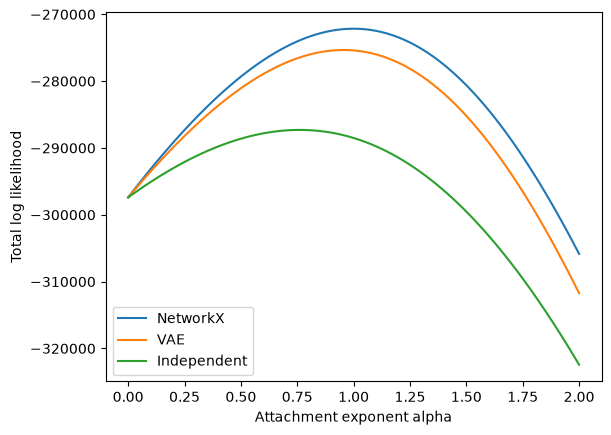

In [13]:
attachment_kernel = ev.attachment_kernel_experiment(
    evaluation_collections, bootstrap_samples=BOOTSTRAP_SAMPLES
)

degree class is the collection of eligible parents taht currently have the same number of edges. This tests whether the generated graph select a degree class as often as the BA rule says it should.

for each arrival, we look at the degrees in the graph before the new edge is added. We look at each degree class and add the expected count to a bin and the observed coutn to a bin. at the end we find the ratio across all degree bins.

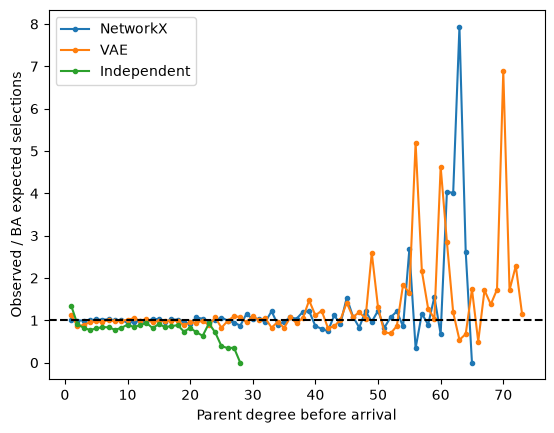

In [14]:
selected_parent_degree = ev.selected_parent_degree_experiment(evaluation_collections)

## 3. Degree distributions and exact finite-size expectations

degree distribution is asking: if we randomly select one node, what is the porbability of it having 1 edge, 2 edge, etc. BA has a set general formula for this.

NetworkX PMF total variation vs NetworkX: 0.0 node fractions with degree >= threshold: {5: 0.0691070556640625, 10: 0.021270751953125}
VAE PMF total variation vs NetworkX: 0.0482177734375 node fractions with degree >= threshold: {5: 0.0624237060546875, 10: 0.0202789306640625}
Independent PMF total variation vs NetworkX: 0.0795135498046875 node fractions with degree >= threshold: {5: 0.066314697265625, 10: 0.0159759521484375}


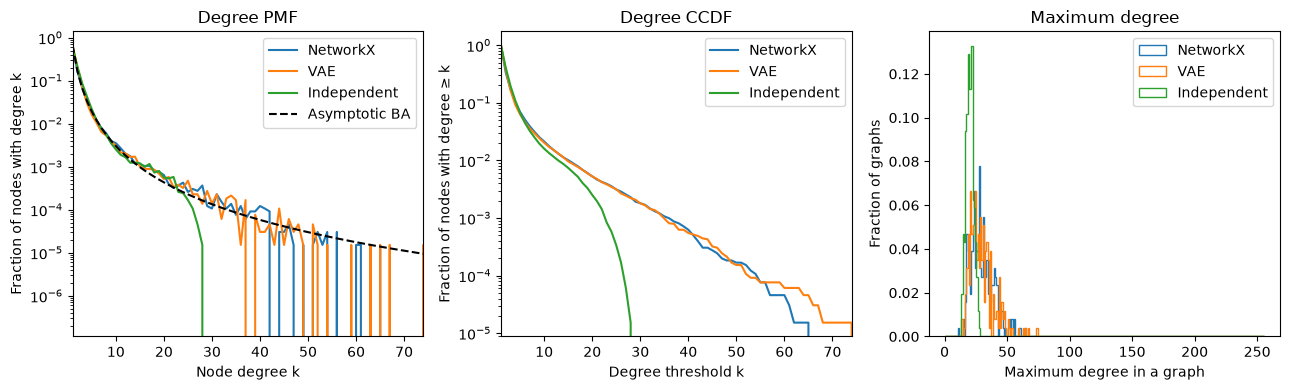

In [15]:
degree_distribution = ev.degree_distribution_experiment(evaluation_collections)

I'm not sure on interpretation here...we're basically seeing that vae and independent graphs have, on avera, fewer leaves and more degree-2 nodes than a 64-node BA graph is expected to have. But, only by +-3.

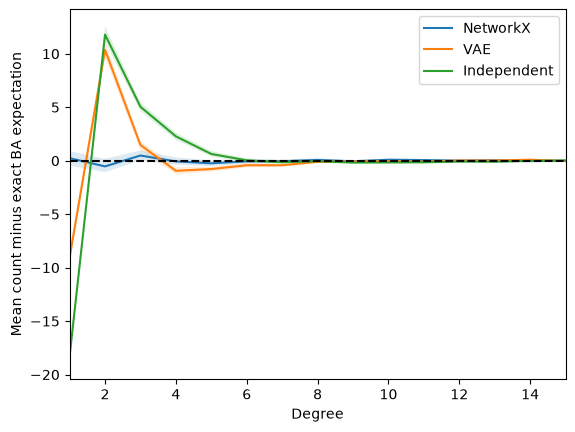

In [16]:
finite_size_counts = ev.finite_size_degree_counts_experiment(
    evaluation_collections,
    num_nodes=config.num_nodes,
    bootstrap_samples=BOOTSTRAP_SAMPLES,
)

## 4. Degree growth by arrival age

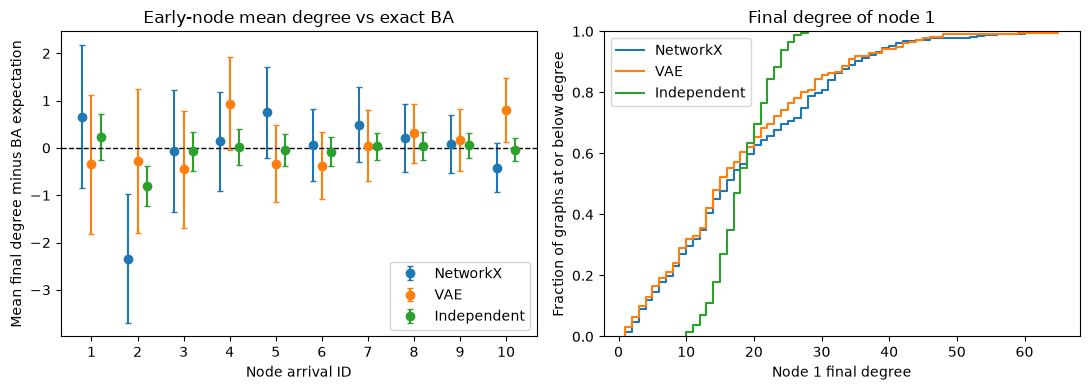

In [17]:
degree_by_age = ev.degree_by_age_experiment(
    evaluation_collections, early_nodes=len(early_nodes)
)

## 5. Reinforcement and temporal dependence

Unborn nodes and constant-degree correlations are undefined; these appear as missing values. Conditional-growth plots mark sparse bins.

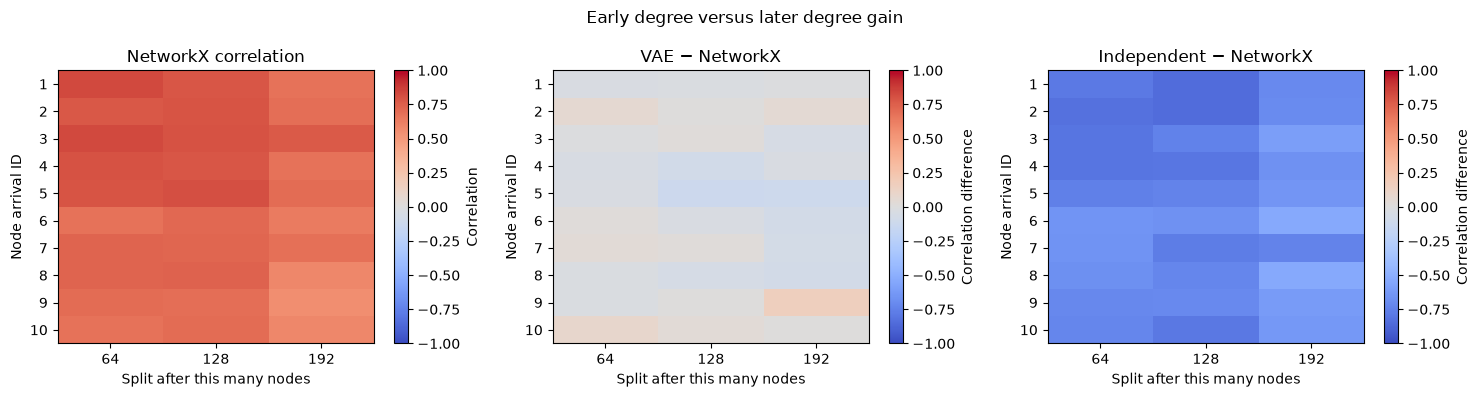

In [18]:
reinforcement = ev.reinforcement_experiment(
    evaluation_collections,
    node_ids=early_nodes,
    bootstrap_samples=BOOTSTRAP_SAMPLES,
)

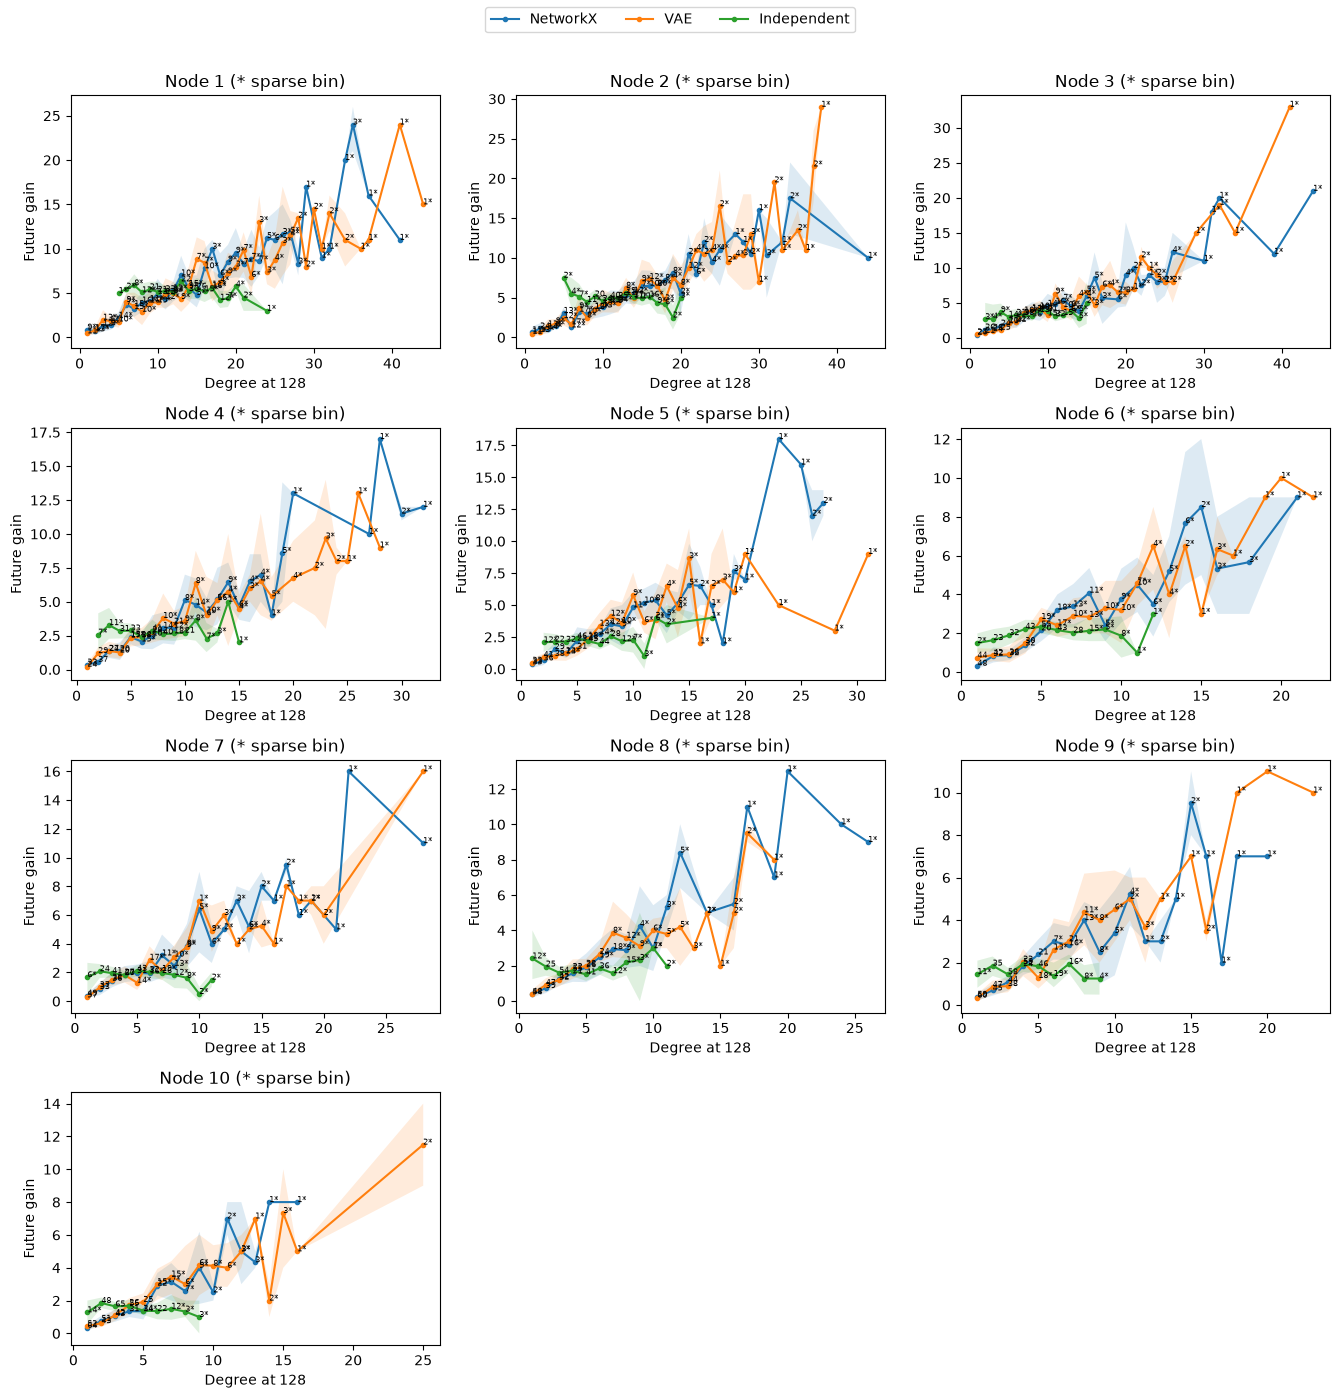

In [19]:
conditional_growth = ev.conditional_future_growth_experiment(
    evaluation_collections,
    node_ids=early_nodes,
    bootstrap_samples=BOOTSTRAP_SAMPLES,
)

Lag-one residual correlations: {'NetworkX': -0.000929604034742245, 'VAE': -0.0010461363055758405, 'Independent': -0.004569864856214179}


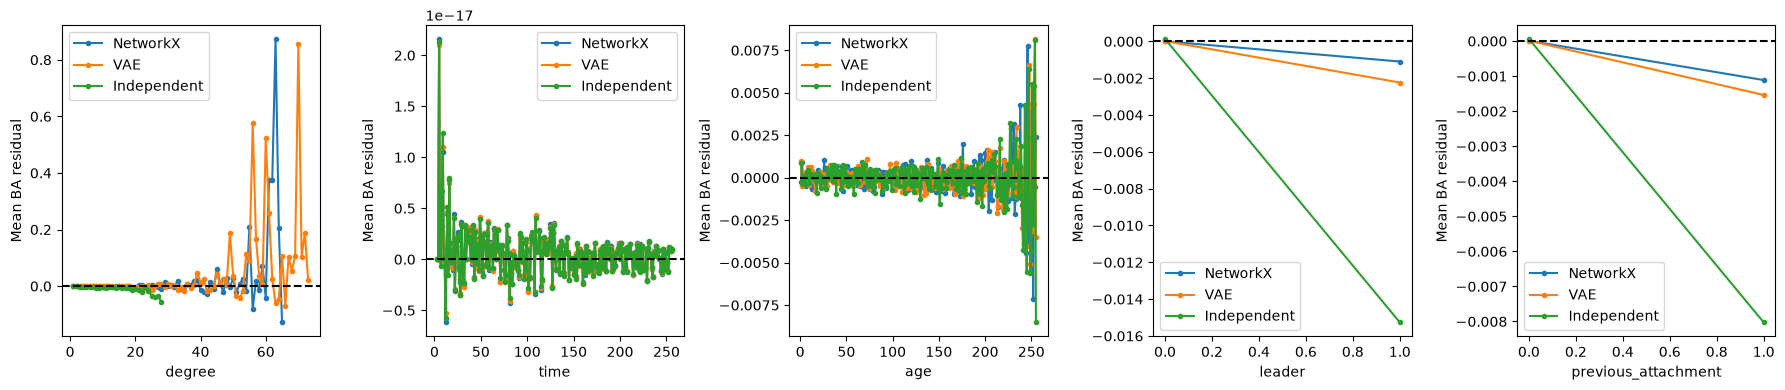

In [20]:
attachment_residuals = ev.attachment_residuals_experiment(evaluation_collections)

## 6. Hub formation and persistence

NetworkX leader persistence: 0.87109375
VAE leader persistence: 0.84375
Independent leader persistence: 0.8046875


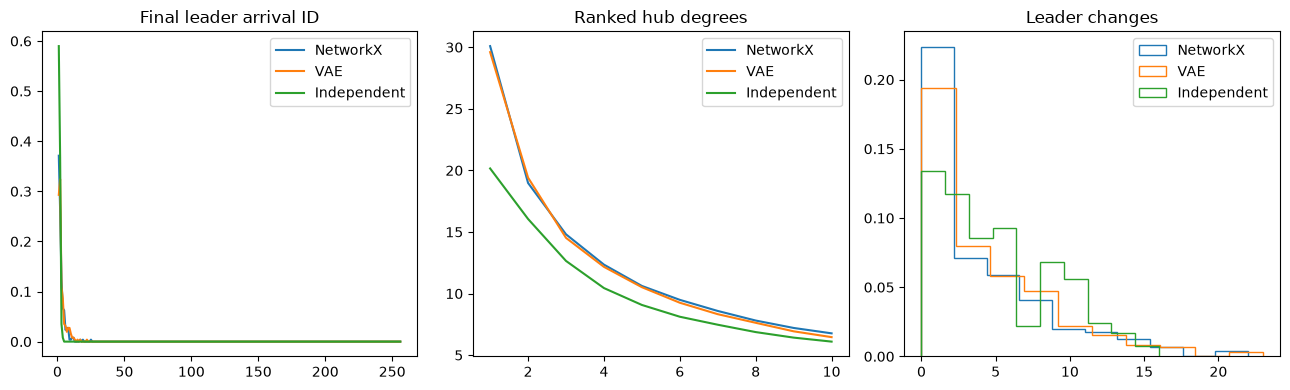

In [21]:
hub_dynamics = ev.hub_dynamics_experiment(evaluation_collections)

## 7. Dependencies beyond node 1

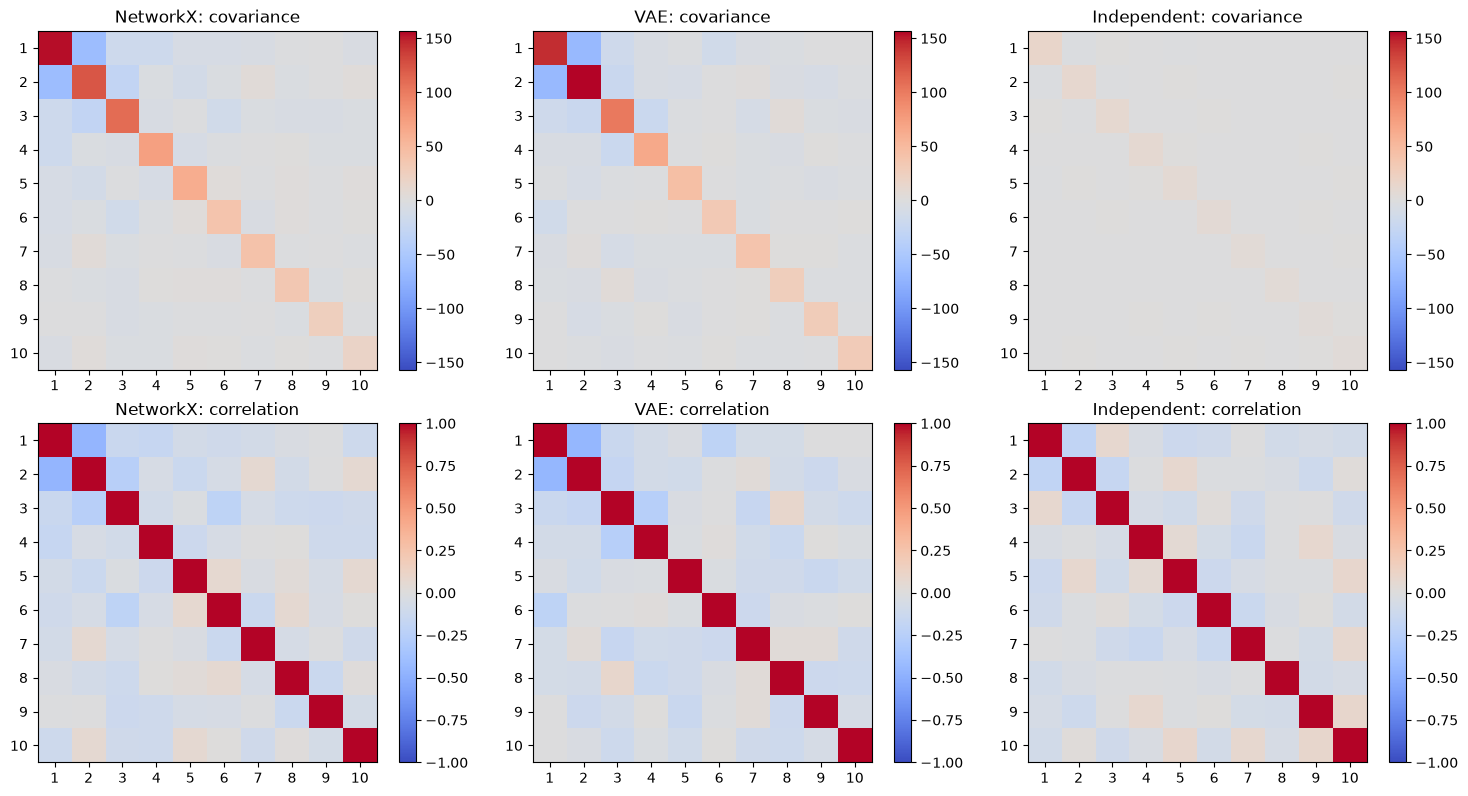

In [22]:
early_covariance = ev.early_node_covariance_experiment(
    evaluation_collections,
    node_ids=early_nodes,
    bootstrap_samples=BOOTSTRAP_SAMPLES,
)

NetworkX joint counts: {(8, 16, 1): 16, (8, 16, 2): 8, (8, 24, 1): 13, (8, 24, 2): 8}
VAE joint counts: {(8, 16, 1): 13, (8, 16, 2): 11, (8, 24, 1): 9, (8, 24, 2): 5}
Independent joint counts: {(8, 16, 1): 12, (8, 16, 2): 2, (8, 24, 1): 8, (8, 24, 2): 7}


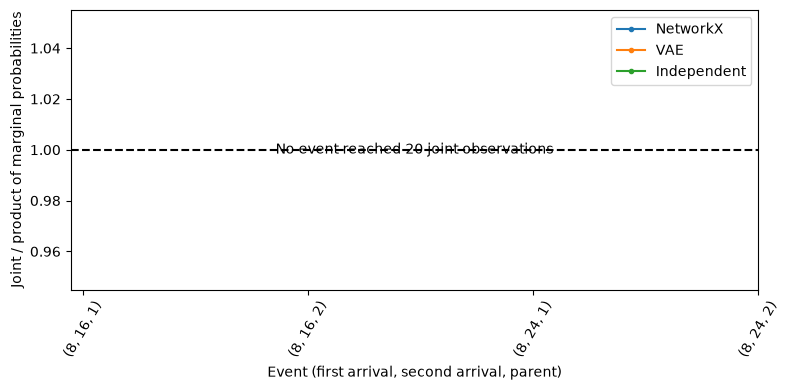

In [23]:
joint_attachments = ev.joint_attachment_experiment(
    evaluation_collections,
    arrival_pairs=[(8, 16), (8, 24)],
    candidate_parents=(1, 2),
    bootstrap_samples=BOOTSTRAP_SAMPLES,
)

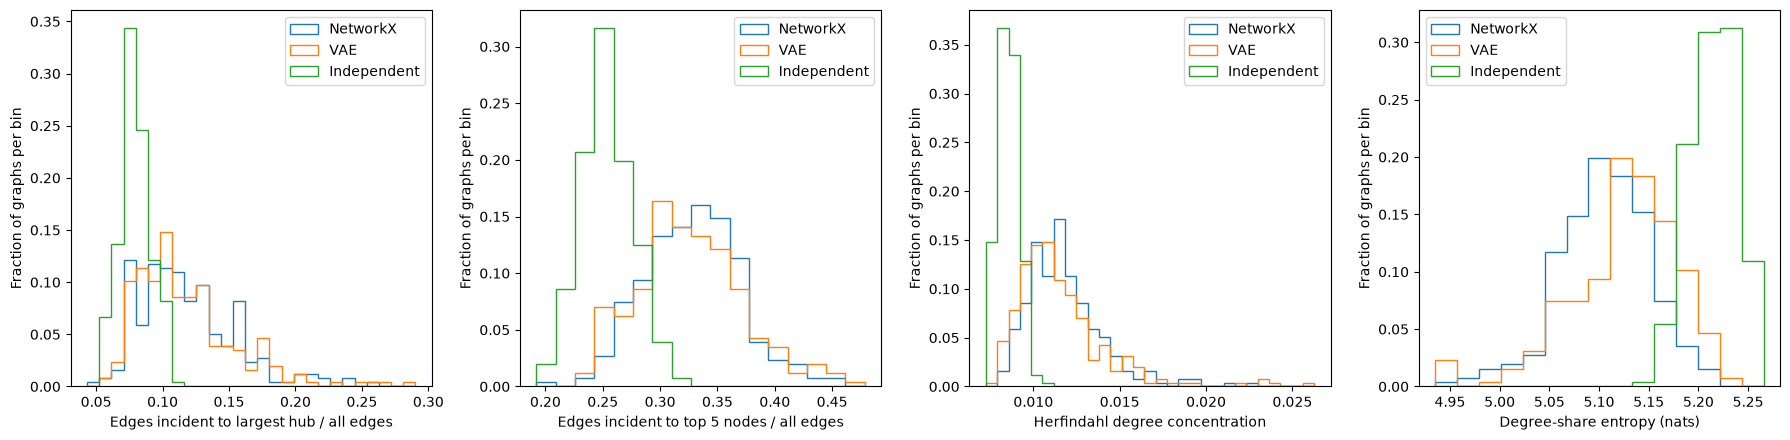

In [24]:
hub_concentration = ev.hub_concentration_experiment(evaluation_collections)

## 8. Tree geometry

NetworkX geometry Wasserstein: {'mean_depth': 0.0, 'max_depth': 0.0, 'diameter': 0.0, 'radius': 0.0, 'branch_count': 0.0, 'largest_branch_fraction': 0.0, 'branch_balance': 0.0}
VAE geometry Wasserstein: {'mean_depth': 0.0657196044921875, 'max_depth': 0.26171875, 'diameter': 0.28515625, 'radius': 0.16015625, 'branch_count': 1.1171875, 'largest_branch_fraction': 0.026348039215686275, 'branch_balance': 0.030412901152690457}
Independent geometry Wasserstein: {'mean_depth': 0.1580810546875, 'max_depth': 0.40234375, 'diameter': 0.95703125, 'radius': 0.4375, 'branch_count': 6.76171875, 'largest_branch_fraction': 0.09192708333333333, 'branch_balance': 0.05660890230432307}


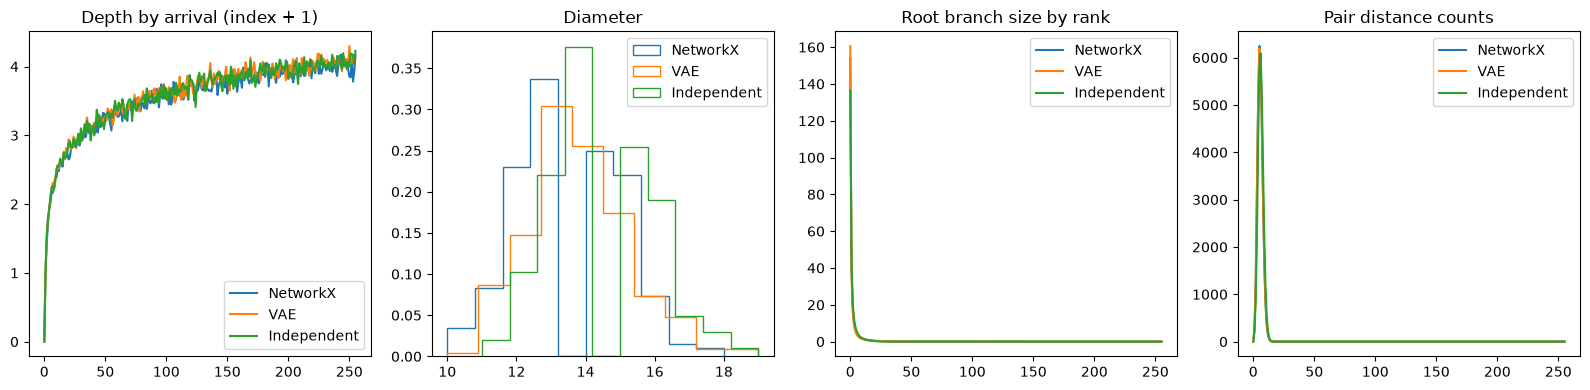

In [25]:
tree_geometry = ev.tree_geometry_experiment(evaluation_collections)

## 9. Degree correlations along edges

NetworkX assortativity: [-0.19464314 -0.16350835 -0.18150214 -0.19528502 -0.22436149 -0.22373236
 -0.21132233 -0.23501436 -0.21275006 -0.25584118 -0.24172748 -0.1961525
 -0.16563239 -0.19636841 -0.18759587 -0.20004629 -0.1634582  -0.22694774
 -0.16526935 -0.18497589 -0.23931629 -0.23455327 -0.21341157 -0.16255034
 -0.2278893  -0.19843684 -0.1695689  -0.15848346 -0.16201405 -0.24577312
 -0.21141204 -0.17580108 -0.21596669 -0.21315636 -0.14322001 -0.1954358
 -0.1984123  -0.18809632 -0.24189223 -0.23178204 -0.17557279 -0.18282186
 -0.21536637 -0.20773743 -0.20224492 -0.1609248  -0.18956894 -0.17224089
 -0.1466817  -0.17989708 -0.16318914 -0.16036407 -0.14410369 -0.15498131
 -0.18858617 -0.19333306 -0.23363728 -0.19022548 -0.19298125 -0.16976557
 -0.22079163 -0.25472276 -0.16092128 -0.31135985 -0.18573544 -0.19743424
 -0.16128191 -0.21105775 -0.19225217 -0.17739749 -0.17188981 -0.18619236
 -0.18228458 -0.19324593 -0.23408418 -0.22035948 -0.21003153 -0.17936402
 -0.28090567 -0.20629217 -0.1

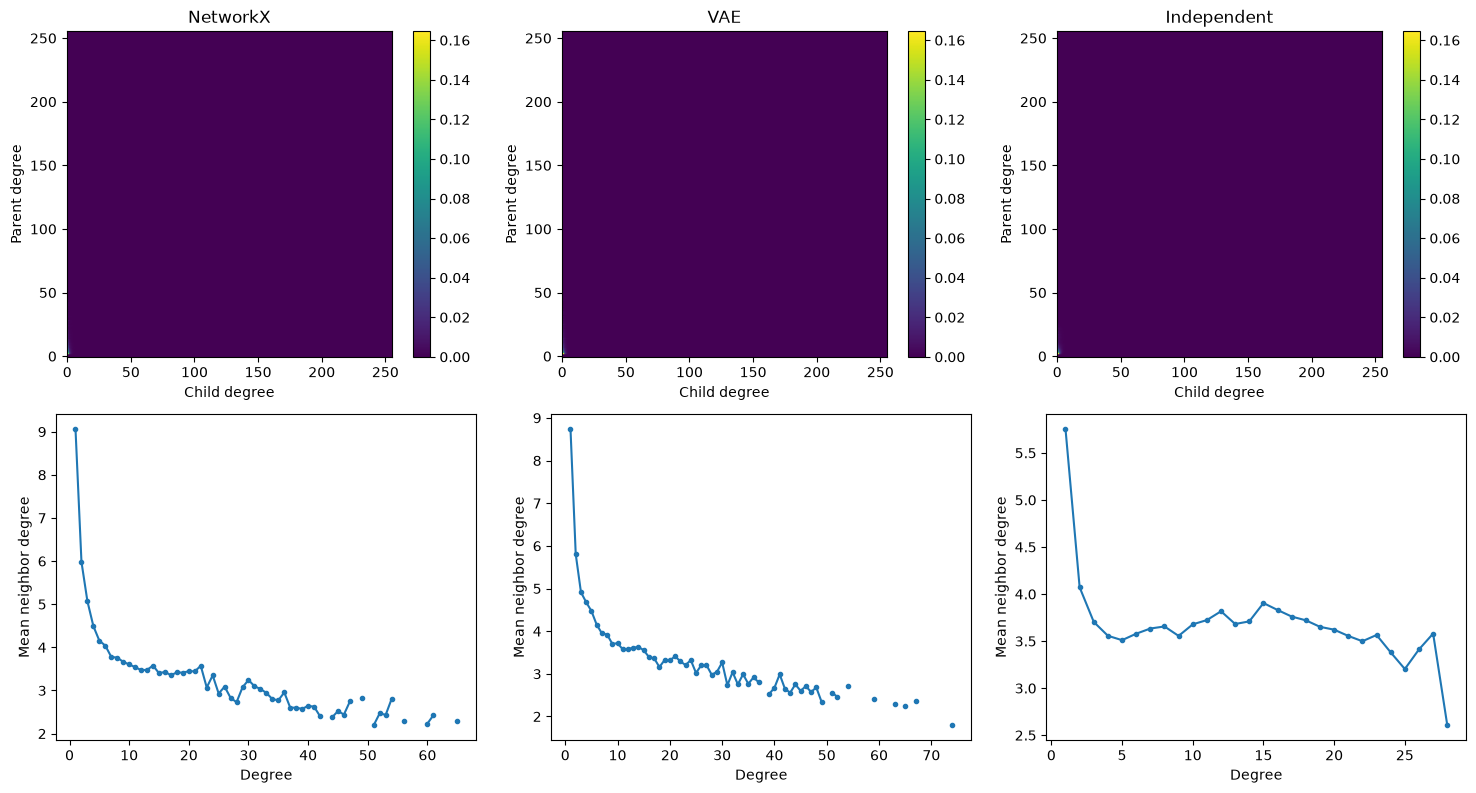

In [26]:
edge_correlations = ev.edge_degree_correlation_experiment(evaluation_collections)

## 10. Latent diagnostics

The ablation cell generates `LATENT_SAMPLES × SAMPLES_PER_LATENT` replicate graphs, plus comparison collections. Whole-latent shuffling preserves sharing within each graph; it is a seed reassignment control. Probes use fresh prior latent/generated-graph pairs with a held-out split.

Hub/leaf summary: {
  "Normal": {
    "max_degree_mean": 31.99,
    "max_degree_sd": 11.522042993648078,
    "leaf_fraction_mean": 0.629453125,
    "leaf_fraction_sd": 0.021710209697233546
  },
  "Zero": {
    "max_degree_mean": 25.77,
    "max_degree_sd": 3.959019876666242,
    "leaf_fraction_mean": 0.59046875,
    "leaf_fraction_sd": 0.01813354248361446
  },
  "Shuffled": {
    "max_degree_mean": 31.7,
    "max_degree_sd": 11.776110040109495,
    "leaf_fraction_mean": 0.629609375,
    "leaf_fraction_sd": 0.02132599883720975
  },
  "Averaged": {
    "max_degree_mean": 21.18,
    "max_degree_sd": 3.571435497828781,
    "leaf_fraction_mean": 0.597421875,
    "leaf_fraction_sd": 0.016261309620619474
  },
  "Independent": {
    "max_degree_mean": 20.83,
    "max_degree_sd": 3.5278258964347367,
    "leaf_fraction_mean": 0.5958984375,
    "leaf_fraction_sd": 0.015218989090145855
  }
}


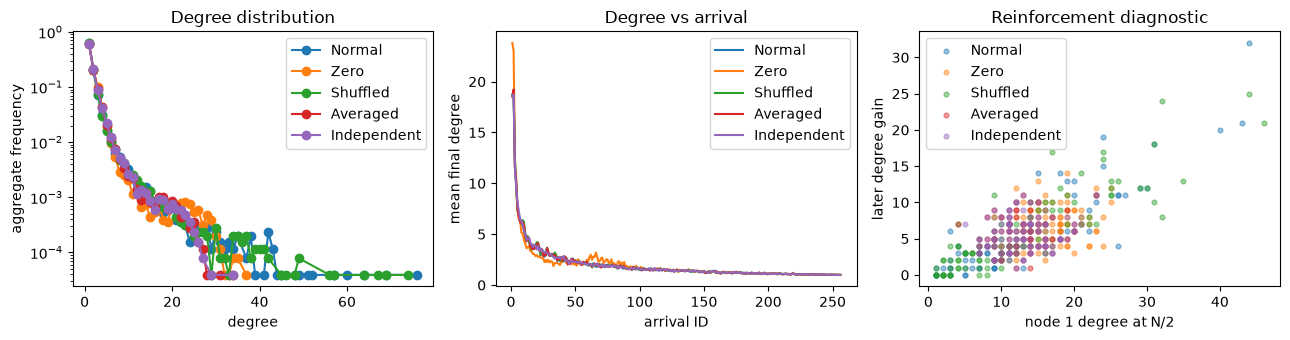

Reinforcement: {
  "Normal": {
    "pearson": 0.8694940490687387,
    "bootstrap_95pct": [
      0.8030831351872685,
      0.9192540549435212
    ],
    "undefined_resamples": 0
  },
  "Zero": {
    "pearson": 0.18304187041016445,
    "bootstrap_95pct": [
      -0.037615192765987696,
      0.3720733045224358
    ],
    "undefined_resamples": 0
  },
  "Shuffled": {
    "pearson": 0.8707251490963015,
    "bootstrap_95pct": [
      0.8096360595407337,
      0.9193875016443334
    ],
    "undefined_resamples": 0
  },
  "Averaged": {
    "pearson": 0.16919706014715283,
    "bootstrap_95pct": [
      -0.03351305232092807,
      0.35156240114852033
    ],
    "undefined_resamples": 0
  },
  "Independent": {
    "pearson": 0.14453117417274913,
    "bootstrap_95pct": [
      -0.05024791394280356,
      0.31254189507822966
    ],
    "undefined_resamples": 0
  }
}


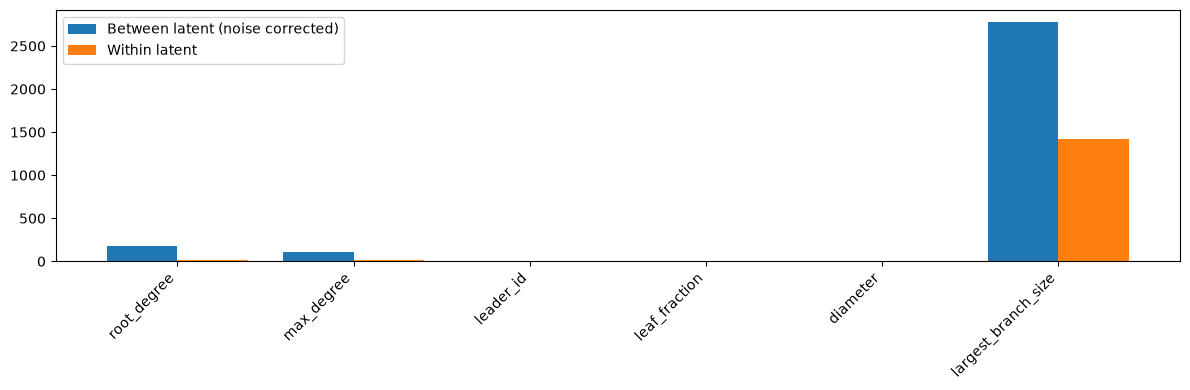

In [27]:
latent_ablation = ev.latent_ablation_experiment(
    generators["vae"],
    seeds=latent_seeds,
    samples_per_latent=SAMPLES_PER_LATENT,
    baseline=generators["independent"],
)

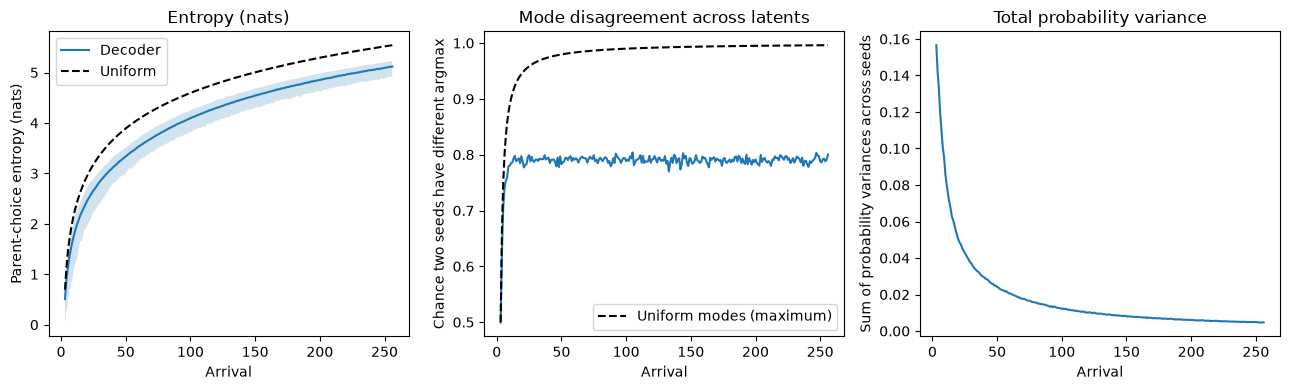

In [28]:
decoder_entropy = ev.decoder_entropy_experiment(
    generators["vae"], seeds=latent_seeds
)

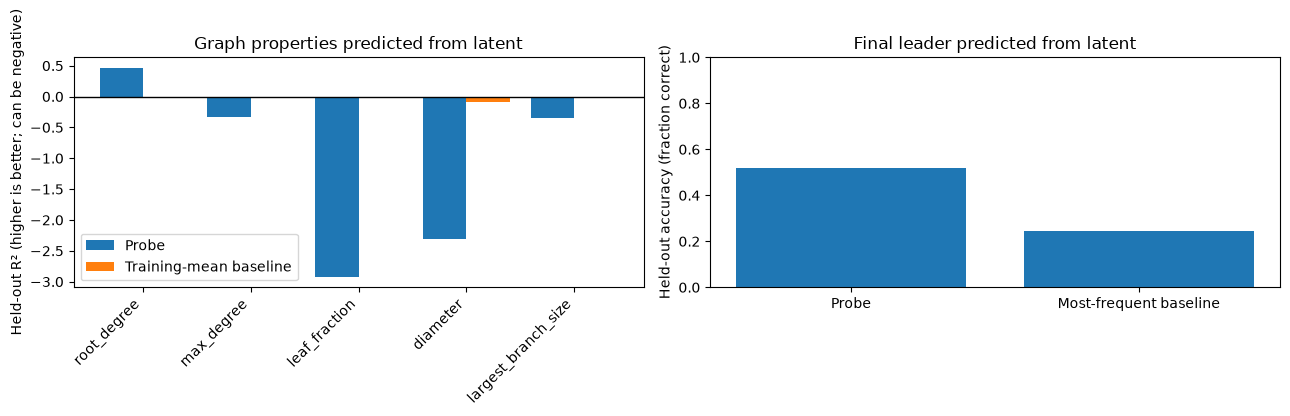

In [29]:
latent_probes = ev.latent_predictability_experiment(
    run, seeds=evaluation_seeds
)

## 11. Distribution-level comparisons

The classifier uses held-out folds. Coverage and diversity refer to the documented graph-feature representation.

VAE {'energy_distance_squared': 0.791303357010654, 'coverage': 0.3125, 'precision': 0.55859375, 'duplicate_rate': 0.0, 'leader_total_variation': 0.13671875}
Independent {'energy_distance_squared': 3.5478220230221127, 'coverage': 0.04296875, 'precision': 0.09375, 'duplicate_rate': 0.0, 'leader_total_variation': 0.32421875}


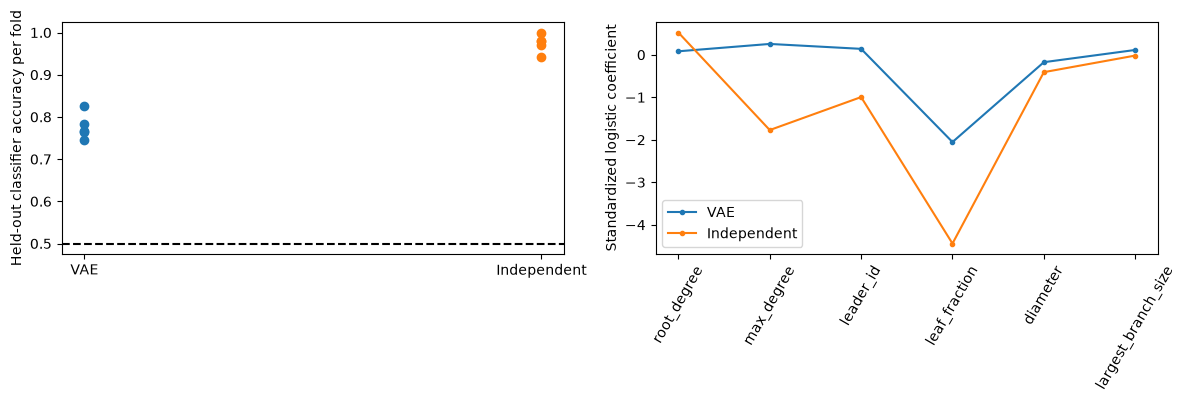

In [30]:
distribution_comparison = ev.distribution_comparison_experiment(
    evaluation_collections, cross_validation_folds=5
)

## 12. Scaling across graph size, latent width, and training seed

**This cell trains new models.** The default is a small smoke-profile sweep: two graph sizes × two latent widths × two training seeds = eight short runs. Use the demo or large profile and expand these settings for scientific measurements. Smoke training is only a workflow check; it is not enough to judge capacity scaling.

N=16, D=4, seed=11: {'ba_wasserstein': 0.31029234855232135, 'reinforcement_rmse': 0.4760857090593718, 'degree_tv': 0.2080078125, 'hub_wasserstein': 2.21875, 'leader_tv': 0.15625, 'diameter_wasserstein': 1.921875, 'kl_per_graph': 0.006700722500681877, 'parameters': 25624, 'decoder_parameters': 6544, 'output_head_multiply_adds': 1024, 'duplicate_rate': 0.0, 'query_ms': np.float64(0.06682299863314256), 'graph_ms': np.float64(0.9800509997148765)}
N=16, D=4, seed=22: {'ba_wasserstein': 0.3021619680695439, 'reinforcement_rmse': 0.44242570316222835, 'degree_tv': 0.2021484375, 'hub_wasserstein': 2.125, 'leader_tv': 0.140625, 'diameter_wasserstein': 1.890625, 'kl_per_graph': 0.002880275947973132, 'parameters': 25624, 'decoder_parameters': 6544, 'output_head_multiply_adds': 1024, 'duplicate_rate': 0.0, 'query_ms': np.float64(0.07167349940573331), 'graph_ms': np.float64(1.0136874989257194)}
N=16, D=8, seed=11: {'ba_wasserstein': 0.29703613362089487, 'reinforcement_rmse': 0.45942773171492185, 'deg

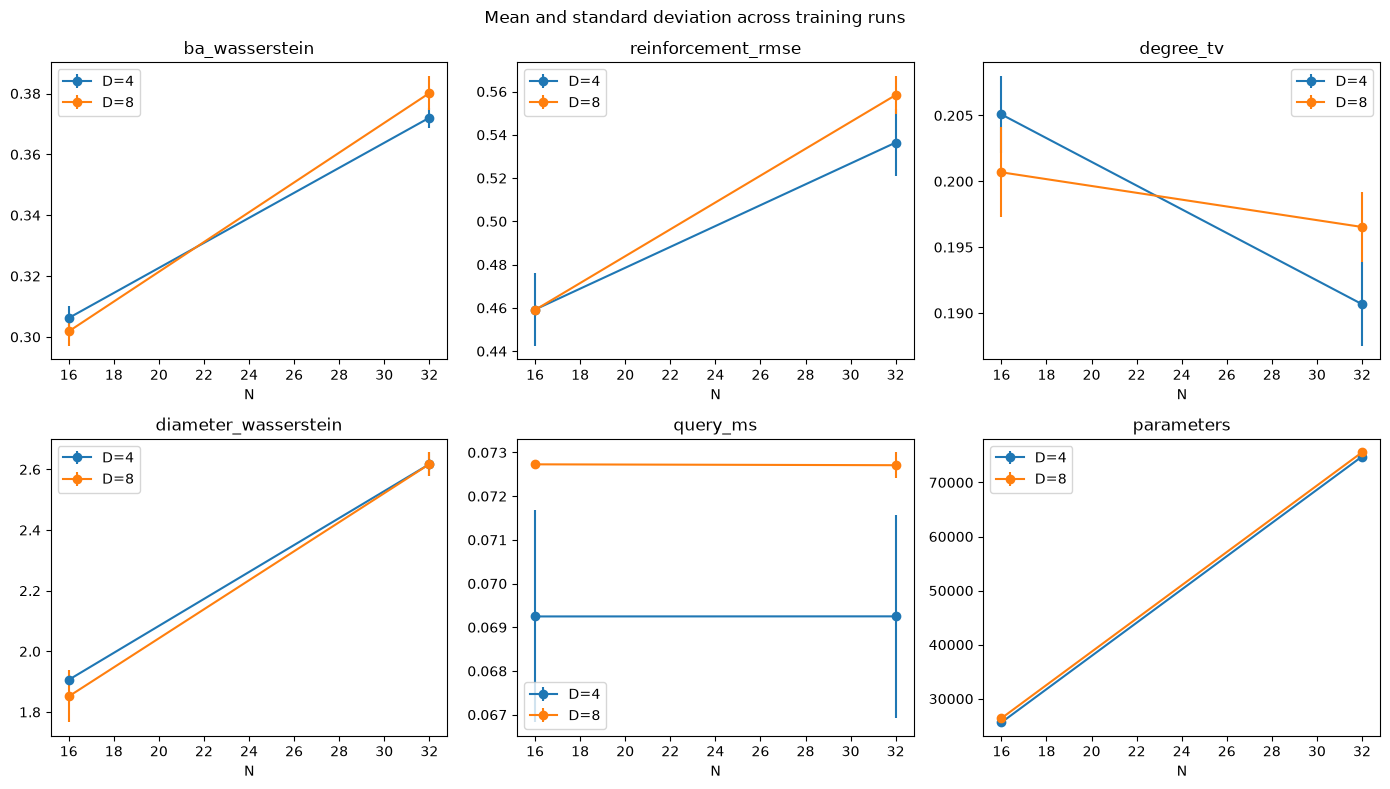

In [31]:
SCALING_PROFILE = "smoke"
SCALING_GRAPH_SIZES = (16, 32)
SCALING_LATENT_DIMS = (4, 8)
SCALING_TRAINING_SEEDS = (11, 22)

scaling_configs = [
    replace(PROFILES[SCALING_PROFILE], num_nodes=n, latent_dim=d)
    for n in SCALING_GRAPH_SIZES
    for d in SCALING_LATENT_DIMS
]
scaling_results = ev.scaling_experiment(
    scaling_configs,
    training_seeds=SCALING_TRAINING_SEEDS,
    bootstrap_samples=BOOTSTRAP_SAMPLES,
)